In [6]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..'))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb
import joblib
import warnings
warnings.filterwarnings('ignore')

## Step 1 — Train all models

In [ ]:
from src.train import run_training

model_info = run_training()

X_train : (1832581, 24) | y_train mean: 0.9924
X_test  : (490408, 24)  | y_test  mean: 1.1337

Training Ridge Regression...
  Train time: 5.9s
  [Ridge               ] MAE=0.3745 | RMSE=0.6004 | MAPE=51.34%
  ✓ Saved models/ridge.pkl

Training XGBoost...
[0]	validation_0-mae:0.70598
[50]	validation_0-mae:0.37174
[100]	validation_0-mae:0.36351
[150]	validation_0-mae:0.36312
[161]	validation_0-mae:0.36320
  Best iteration : 131
  Train time     : 17.8s
  [XGBoost             ] MAE=0.3626 | RMSE=0.5947 | MAPE=51.64%
  ✓ Saved models/xgboost.json

Training LightGBM...
[50]	valid_0's l2: 0.374694
[100]	valid_0's l2: 0.352591
[150]	valid_0's l2: 0.347388
  Best iteration : 148
  Train time     : 15.7s
  [LightGBM            ] MAE=0.3613 | RMSE=0.5892 | MAPE=51.44%
  ✓ Saved models/lightgbm.txt

  MODEL COMPARISON
             MAE    RMSE  MAPE%
model                          
Ridge     0.3745  0.6004  51.34
XGBoost   0.3626  0.5947  51.64
LightGBM  0.3613  0.5892  51.44

✓ Best model by MAE:

## Step 2 — Reload the results to visualize

In [8]:
# Load feature config
FEATURE_COLS = model_info['feature_cols']
TARGET_COL   = model_info['target_col']
BEST_MODEL   = model_info['best_model']

# Load test data để tạo predictions cho chart
X_test = pd.read_parquet('../notebooks/data/processed/X_test.parquet')
y_test = pd.read_parquet('../notebooks/data/processed/y_test.parquet')[TARGET_COL]

# Load metrics
results_df = pd.read_csv('../models/results.csv', index_col='model')

print('Best model :', BEST_MODEL)
print()
print(results_df)

Best model : LightGBM

             MAE    RMSE  MAPE%
model                          
Ridge     0.3745  0.6004  51.34
XGBoost   0.3626  0.5947  51.64
LightGBM  0.3613  0.5892  51.44


In [9]:
# Load các models để predict
ridge_model = joblib.load('../models/ridge.pkl')

xgb_model = xgb.XGBRegressor()
xgb_model.load_model('../models/xgboost.json')

lgb_model = lgb.Booster(model_file='../models/lightgbm.txt')

# Predict
y_pred_ridge = np.clip(ridge_model.predict(X_test), 0, None)
y_pred_xgb   = np.clip(xgb_model.predict(X_test),   0, None)
y_pred_lgb   = np.clip(lgb_model.predict(X_test),    0, None)

print('✓ Predictions ready')

✓ Predictions ready


## Step 3 — Visualizations

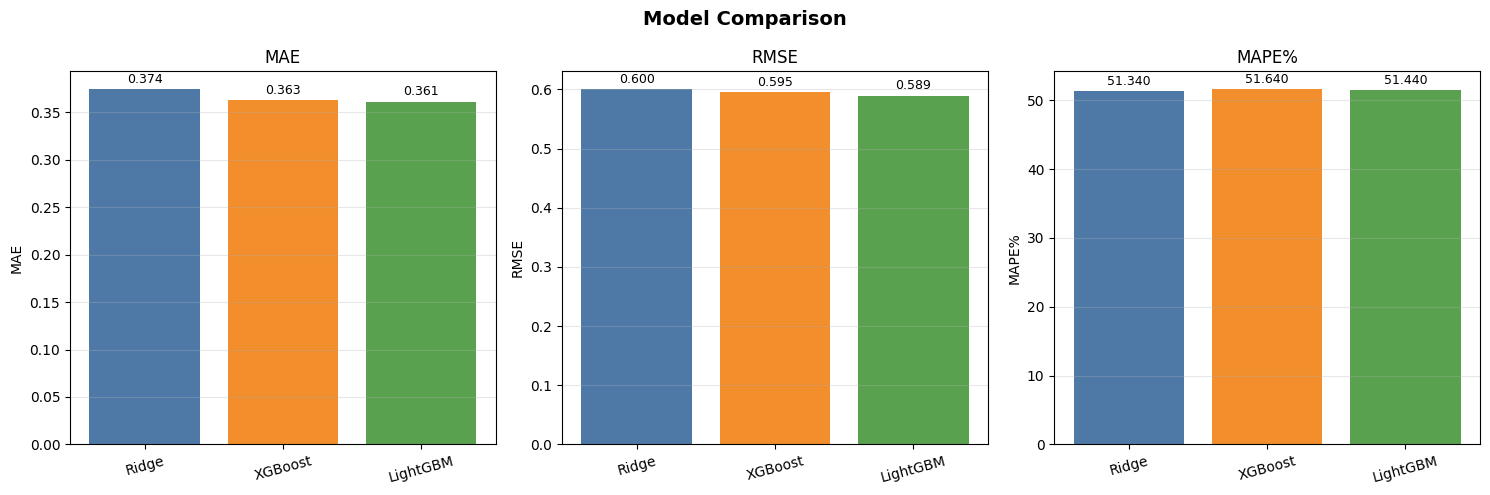

In [10]:
# ── Plot 1: Metrics comparison bar chart ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

colors  = ['#4e79a7', '#f28e2b', '#59a14f']
metrics = ['MAE', 'RMSE', 'MAPE%']

for i, metric in enumerate(metrics):
    vals   = results_df[metric].values
    models = results_df.index.tolist()
    bars   = axes[i].bar(models, vals, color=colors)
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(vals) * 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()
plt.savefig('../models/metrics_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

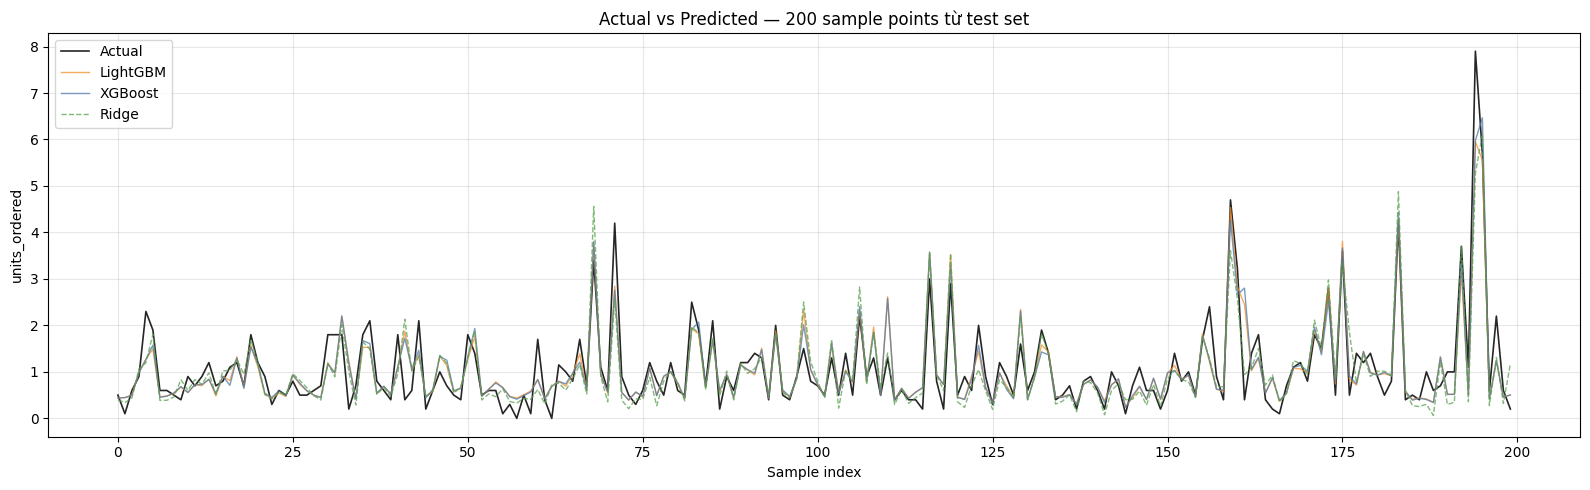

In [ ]:

np.random.seed(42)
sample_idx = np.sort(np.random.choice(len(y_test), size=200, replace=False))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_test.values[sample_idx],   label='Actual',    color='black',   alpha=0.85, linewidth=1.2)
ax.plot(y_pred_lgb[sample_idx],      label='LightGBM',  color='#f28e2b', alpha=0.75, linewidth=1.0)
ax.plot(y_pred_xgb[sample_idx],      label='XGBoost',   color='#4e79a7', alpha=0.75, linewidth=1.0)
ax.plot(y_pred_ridge[sample_idx],    label='Ridge',     color='#59a14f', alpha=0.75, linewidth=1.0, linestyle='--')
ax.set_title('Actual vs Predicted — 200 sample points from test set')
ax.set_xlabel('Sample index')
ax.set_ylabel('units_ordered')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../models/actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()

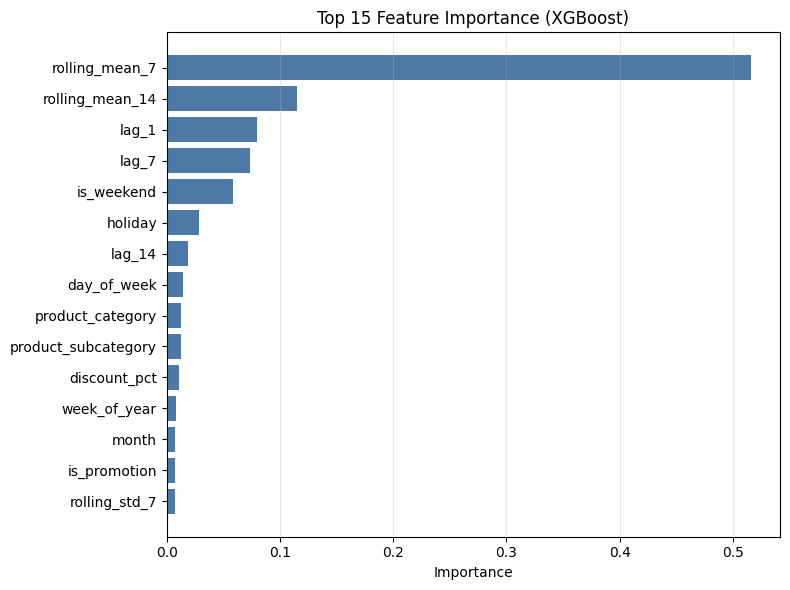

Top 5 features:
        feature  importance
     is_weekend    0.058691
          lag_7    0.073793
          lag_1    0.079615
rolling_mean_14    0.114995
 rolling_mean_7    0.515867


In [12]:
# ── Plot 3: Feature Importance (XGBoost) ─────────────────────────────────────
importance_df = (
    pd.DataFrame({
        'feature'   : FEATURE_COLS,
        'importance': xgb_model.feature_importances_,
    })
    .sort_values('importance', ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df['feature'], importance_df['importance'], color='#4e79a7')
ax.set_title('Top 15 Feature Importance (XGBoost)')
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 5 features:')
print(importance_df.tail(5)[['feature', 'importance']].to_string(index=False))

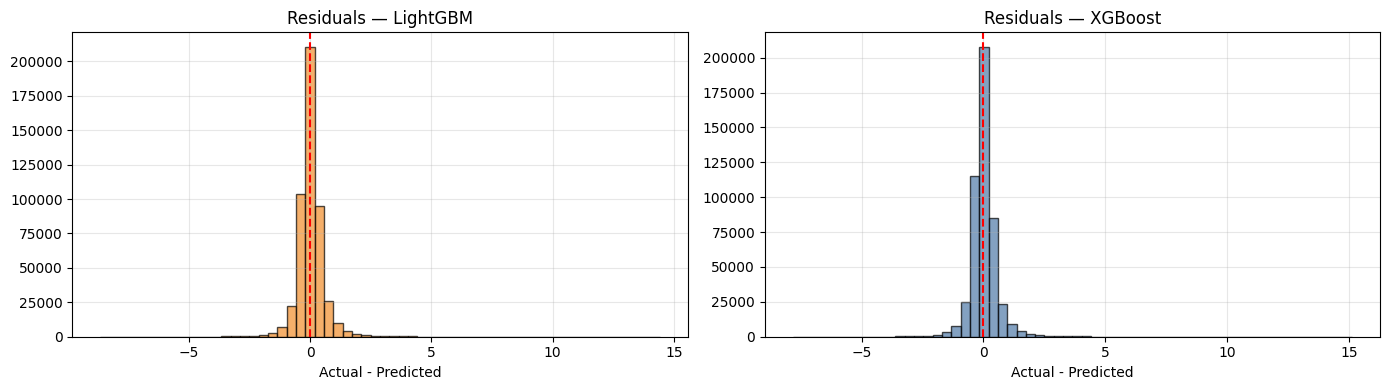

✓ Training & evaluation xong. Chạy notebook 03 để demo API.


In [ ]:
# ── Plot 4: Residual distribution ─────────────────────────────────────────────
residuals_lgb = y_test.values - y_pred_lgb
residuals_xgb = y_test.values - y_pred_xgb

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(residuals_lgb, bins=60, color='#f28e2b', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residuals — LightGBM')
axes[0].set_xlabel('Actual - Predicted')
axes[0].grid(alpha=0.3)

axes[1].hist(residuals_xgb, bins=60, color='#4e79a7', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residuals — XGBoost')
axes[1].set_xlabel('Actual - Predicted')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../models/residuals.png', dpi=120, bbox_inches='tight')
plt.show()
